In [16]:
import numpy as np
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from parsimonious_ensembles.optimize_weights import multiplicative_gradient, compute_loss, compute_loss_log_likelihood
from parsimonious_ensembles.utils import cross_val_split

# Set Directories

In [17]:
main_dir = ".."
fig_dir = f"{main_dir}/figures/hsp90"
data_dir = f"{main_dir}/data/likelihoods"


# Set Plotting Info

In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use(f"../my_style.mplstyle") # Use stylefile defined
plt.style.use("seaborn-v0_8-colorblind") # Use colorscheme from colorblind seaborn
mpl.rcParams['text.usetex'] = True  # Uncomment for latex font in plots
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color'] # Save color list for reference

# Load Likelihood Matrix

In [ ]:
log_likelihood = jnp.load(f"{data_dir}/hsp90/log_likelihood_cryojax.npy")
num_images, num_structures = jnp.shape(log_likelihood)
print(f"num images: {num_images}")
print(f"num structures: {num_structures}")


num images: 100000
num structures: 20


/Users/levans/venvs/parsimonious_ensembles/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


# Define ground truth weights
Here, this is based on knowledge of the log likelihood matrix loaded above, and it's data generating process

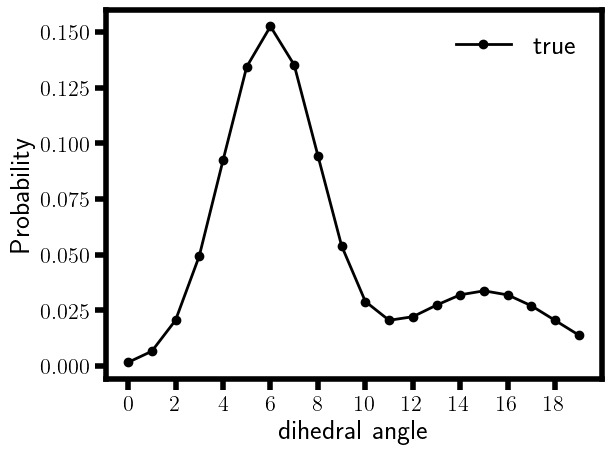

In [20]:
import numpyro.distributions as numpyro_dist

def GaussianMixture1D(weights, means, std_devs):
    weights = jnp.array(weights)
    means = jnp.array(means)
    std_devs = jnp.array(std_devs)
    mixing_dist = numpyro_dist.Categorical(probs=weights/jnp.sum(weights))
    component_dist = numpyro_dist.Normal(loc=means, scale=std_devs) 
    return numpyro_dist.MixtureSameFamily(mixing_dist, component_dist) 

weights = [1., 1./3.]
means = [6., 15.]
std_devs = [2.0, 3.0]
mixture = GaussianMixture1D(weights, means, std_devs)
samples = mixture.sample(jax.random.PRNGKey(0), (10000,))
 
# compute pdf output on a 1d grid
x = jnp.linspace(0, 19, 20)
dx = x[1] - x[0]
    
# normalize output to integrate to 1 on the grid 
true_weights = jnp.exp(mixture.log_prob(x))
true_weights /= dx*true_weights.sum() 
plt.plot(x, true_weights, label='true', color="k", marker='.', markersize=12)
plt.xticks(jnp.arange(0, 20, 2))
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend()


# Optimize Weights

In [21]:
nodes = jnp.linspace(0, 19, 20) + 0.5 

# Using all default info
ensemble_weights, info = multiplicative_gradient(log_likelihood)

# Gather info
losses = info["losses"]
original_num_iterations = info["final_idx"]

exiting!
#iterations at exit: 15


# Plot final weights

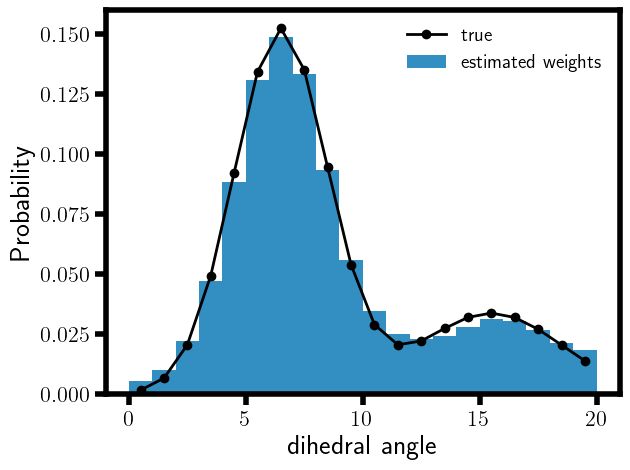

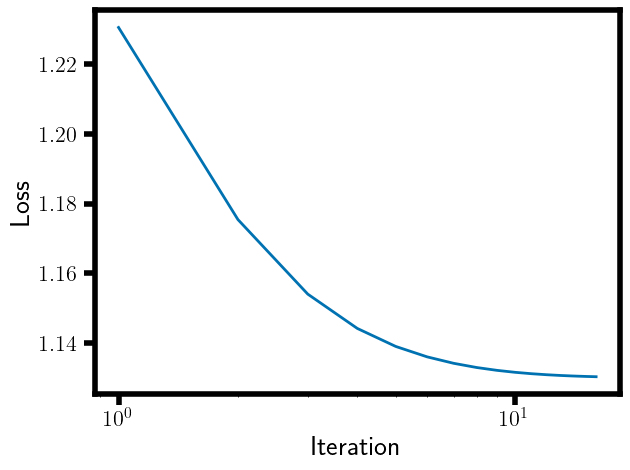

In [22]:
plt.figure()
plt.plot(nodes, true_weights, label='true', color="k", marker='.', markersize='12')
plt.bar(nodes, ensemble_weights, width=dx, label="estimated weights", color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(f"{fig_dir}/weight_true_max_iter.png", dpi=300)

iterations = jnp.arange(0, len(losses), 1)
plt.figure()
plt.semilogx(iterations+1, losses, linestyle="-")
plt.ylabel("Loss")
plt.xlabel("Iteration")
plt.tight_layout()
#plt.savefig(f"{fig_dir}/weight_errors_both_methods.png", dpi=300)




### Now, lets instead iterate for a long number of iterations, to compare different stopping criteria

In [23]:
# Using all default info
ensemble_weights, info = multiplicative_gradient(log_likelihood, tol=-1, max_iterations=10000, weights_frequency=1)

# Gather info
losses = info["losses"]
gaps = info["gaps"]
weights = info["weights"]
iterations = np.arange(0, len(losses))

# Compare these weights against the original ones
weights_original = weights[original_num_iterations, :]

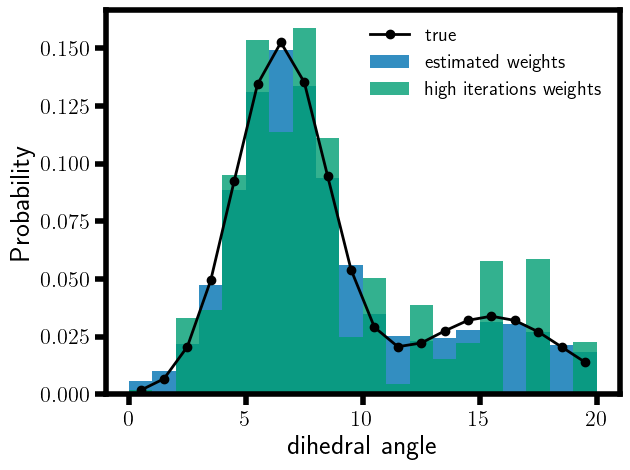

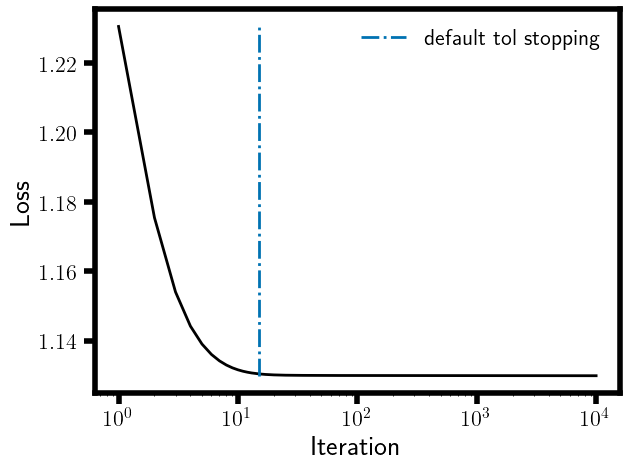

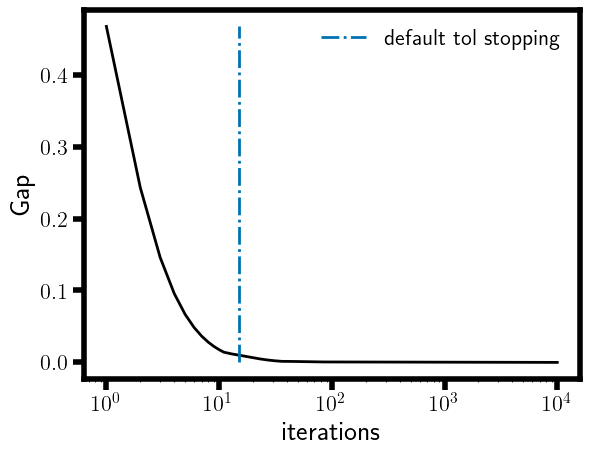

In [24]:

plt.figure()
plt.plot(nodes, true_weights, label='true', color="k", marker='.', markersize='12')
plt.bar(nodes, weights_original, width=dx, label="estimated weights", color="C0", alpha=0.8)
plt.bar(nodes, ensemble_weights, width=dx, label="high iterations weights", color="C1", alpha=0.8)
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend(fontsize=14)
plt.tight_layout()
#plt.savefig(f"{fig_dir}/weight_true_max_iter.png", dpi=300)

# Plot loss
iterations = jnp.arange(0, len(losses), 1)
plt.figure()
plt.semilogx(iterations+1, losses, linestyle="-", c='k')
plt.vlines(original_num_iterations, ymin=jnp.min(losses), ymax=jnp.max(losses), colors='C0', linestyles="-.", label="default tol stopping")
plt.ylabel("Loss")
plt.xlabel("Iteration")
plt.tight_layout()
plt.legend(fontsize=16)


# Plot gaps
plt.figure()
# Here plotting a semilog plot, and shifting indices so 0 doesn't show up
plt.semilogx(iterations+1, gaps, c='k')
plt.vlines(original_num_iterations, ymin=jnp.min(gaps), ymax=jnp.max(gaps), colors='C0', linestyles="-.", label="default tol stopping")
plt.xlabel('iterations')
plt.ylabel('Gap') 
plt.legend(fontsize=16)




# Find alternate early stopped weights by cross validation

In [25]:
key =jax.random.PRNGKey(4)
log_likelihood_train, log_likelihood_test, train_idx, test_idx = cross_val_split(key, log_likelihood, train_pct=0.8)

# Run MG on the train split
ensemble_weights_train, info_train = multiplicative_gradient(log_likelihood_train, tol=-1, max_iterations=1000, weights_frequency=1)

# Gather info
losses_train = info_train["losses"]
weights_train = info_train["weights"]
iterations = np.arange(0, len(losses_train))

# Normalize, likelihood of test data, and compute test loss with MG weights on train
losses_test = []
likelihood_test = jnp.exp(log_likelihood[test_idx, :] - jnp.max(log_likelihood_test, 1)[:, jnp.newaxis])
for k in range(len(losses_train)):
    weights = weights_train[k, :]
    loss_test = compute_loss(weights, likelihood_test)
    losses_test.append(loss_test)
losses_test = jnp.stack(losses_test)

# Compute where test loss starts to increase
# TODO: this needs to be smoothed, e.g, exponential smoothing
k = 0
while True and k<len(losses_test):
    if losses_test[k+1] > losses_test[k]:
        cross_val_idx = k + 1
        break
    else:
        k = k+1 
print(f"the cross_val_idx is {cross_val_idx}")

the cross_val_idx is 28


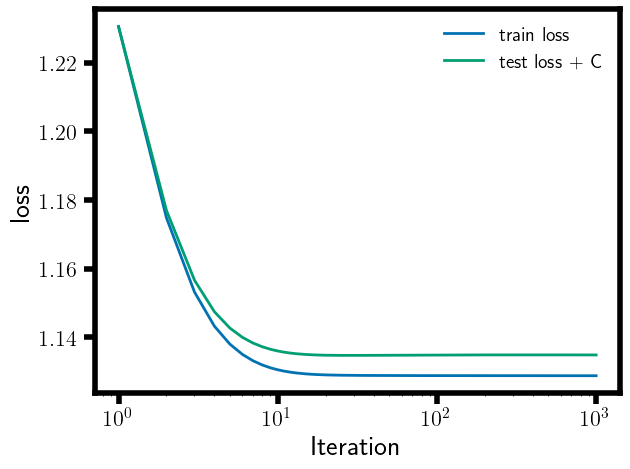

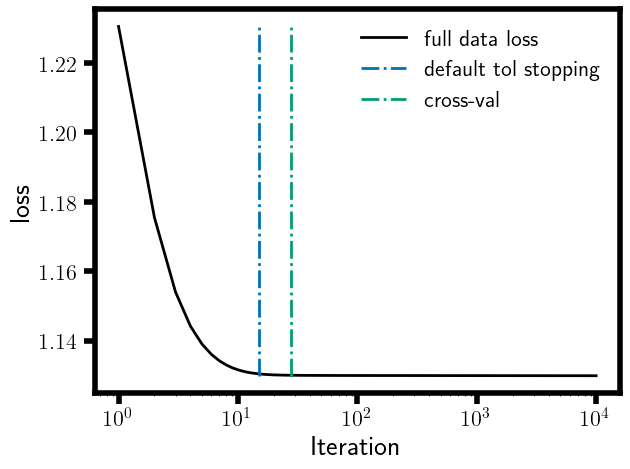

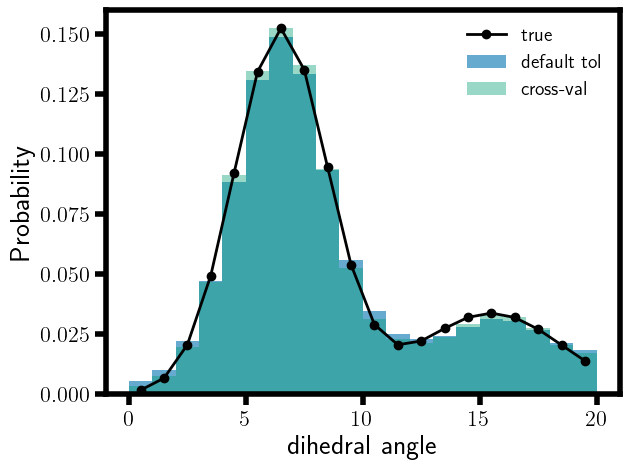

In [26]:
iterations = jnp.arange(0, len(losses_train), 1)
plt.semilogx(iterations+1, losses_train, label="train loss")
plt.semilogx(iterations+1, losses_test, label="test loss + C")
plt.ylabel("loss")
plt.xlabel("Iteration")
plt.legend(fontsize=14)
plt.tight_layout()
#plt.savefig(f"{#fig_dir}/train_test_hsp90.png", dpi=300)

# Plot loss
iterations = jnp.arange(0, len(losses), 1)
plt.figure()
plt.semilogx(iterations+1, losses, linestyle="-", c='k', label="full data loss")
plt.vlines(original_num_iterations, ymin=jnp.min(losses), ymax=jnp.max(losses), colors='C0', linestyles="-.", label="default tol stopping")
plt.vlines(cross_val_idx, ymin=jnp.min(losses), ymax=jnp.max(losses), colors='C1', linestyles="-.", label="cross-val")
plt.ylabel("loss")
plt.xlabel("Iteration")
plt.tight_layout()
plt.legend(fontsize=16)


plt.figure()
plt.plot(nodes, true_weights, label='true', color="k", marker='.', markersize='12')
plt.bar(nodes, info["weights"][original_num_iterations, :], width=dx, label="default tol", color="C0", alpha=0.6)
plt.bar(nodes, info["weights"][cross_val_idx, :], width=dx, label="cross-val", color="C1", alpha=0.4)
plt.xlabel('dihedral angle')
plt.ylabel('Probability')  
plt.legend(fontsize=14)
plt.tight_layout()
#plt.savefig(f"{fig_dir}/weight_true_max_iter.png", dpi=300)




# Finally, lets look at errors between the true weights and the approximated weights

We'll use the chi-squared divergence, the same one used to define the weight update:

$d(\pi, \rho):= \frac{1}{2}\sum\limits_{j=1}^M \frac{(\pi_j - \rho_j)^2}{\rho_j}$


(This is an example of taking the saved weights, and computing extra info from them)

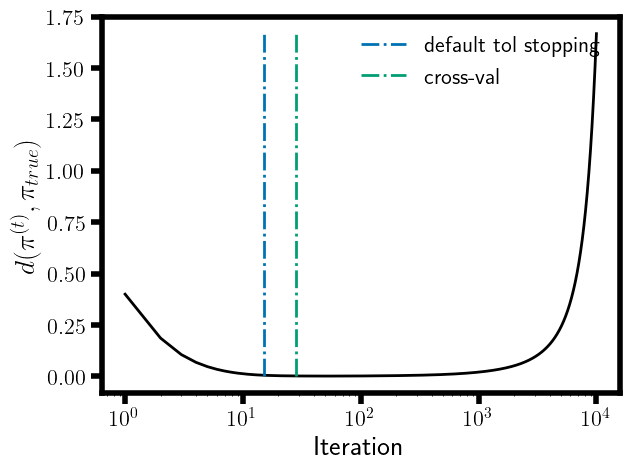

In [27]:
weight_errors = []
weights_all = info["weights"]
for k in range(len(losses)):
    weights = weights_all[k, :]
    error = 0.5*(jnp.sum((true_weights - weights)**2/weights)) 
    weight_errors.append(error)
weight_errors = jnp.stack(jnp.array(weight_errors))

# Plot loss
iterations = jnp.arange(0, len(losses), 1)
plt.figure()
plt.semilogx(iterations+1, weight_errors, linestyle="-", c='k')
plt.vlines(original_num_iterations, ymin=jnp.min(weight_errors), ymax=jnp.max(weight_errors), colors='C0', linestyles="-.", label="default tol stopping")
plt.vlines(cross_val_idx, ymin=jnp.min(weight_errors), ymax=jnp.max(weight_errors), colors='C1', linestyles="-.", label="cross-val")
plt.ylabel("$d(\\pi^{(t)}, \\pi_{true})$")
plt.xlabel("Iteration")
plt.tight_layout()
plt.legend(fontsize=16, loc='upper right')


